In [70]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# Load training and scheduling datasets
df_train = pd.read_csv('DataTrain.csv')
df_schedule = pd.read_csv('DataSchedule.csv')

print(f"Training data shape: {df_train.shape}")
print(f"Schedule data shape: {df_schedule.shape}\n")

# Display initial rows and standard descriptive statistics
display(df_train.head())

print("\nDescriptive Statistics (Training Data)")
display(df_train.describe())

Training data shape: (20631, 26)
Schedule data shape: (13096, 26)



,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
0,1,1,100.0,-0.0007,-0.0004,9046.19,521.66,8138.62,1589.70,554.36,...,392,2388.06,1.3,641.82,2388,8.4195,21.61,47.47,14.62,23.4190
1,1,2,100.0,0.0019,-0.0003,9044.07,522.28,8131.49,1591.82,553.75,...,392,2388.04,1.3,642.15,2388,8.4318,21.61,47.49,14.62,23.4236
2,1,3,100.0,-0.0043,0.0003,9052.94,522.42,8133.23,1587.99,554.26,...,390,2388.08,1.3,642.35,2388,8.4178,21.61,47.27,14.62,23.3442
3,1,4,100.0,0.0007,0.0000,9049.48,522.86,8133.83,1582.79,554.45,...,392,2388.11,1.3,642.35,2388,8.3682,21.61,47.13,14.62,23.3739
4,1,5,100.0,-0.0019,-0.0002,9055.15,522.19,8133.80,1582.85,554.00,...,393,2388.06,1.3,642.37,2388,8.4294,21.61,47.28,14.62,23.4044



--- Descriptive Statistics (Training Data) ---


,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.0,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000
mean,51.506568,108.807862,100.0,-0.000009,0.000002,9065.242941,521.413470,8143.752722,1590.523119,553.367711,...,393.210654,2388.096652,1.3,642.680934,2388.0,8.442146,21.609803,47.541168,1.462000e+01,23.289705
std,29.227633,68.880990,0.0,0.002187,0.000293,22.082880,0.737553,19.076176,6.131150,0.885092,...,1.548763,0.070985,0.0,0.500053,0.0,0.037505,0.001389,0.267087,1.776400e-15,0.108251
min,1.000000,1.000000,100.0,-0.008700,-0.000600,9021.730000,518.690000,8099.940000,1571.040000,549.850000,...,388.000000,2387.900000,1.3,641.210000,2388.0,8.324900,21.600000,46.850000,1.462000e+01,22.894200
25%,26.000000,52.000000,100.0,-0.001500,-0.000200,9053.100000,520.960000,8133.245000,1586.260000,552.810000,...,392.000000,2388.050000,1.3,642.325000,2388.0,8.414900,21.610000,47.350000,1.462000e+01,23.221800
50%,52.000000,104.000000,100.0,0.000000,0.000000,9060.660000,521.480000,8140.540000,1590.100000,553.440000,...,393.000000,2388.090000,1.3,642.640000,2388.0,8.438900,21.610000,47.510000,1.462000e+01,23.297900
75%,77.000000,156.000000,100.0,0.001500,0.000300,9069.420000,521.950000,8148.310000,1594.380000,554.010000,...,394.000000,2388.140000,1.3,643.000000,2388.0,8.465600,21.610000,47.700000,1.462000e+01,23.366800
max,100.000000,362.000000,100.0,0.008700,0.000600,9244.590000,523.380000,8293.720000,1616.910000,556.060000,...,400.000000,2388.560000,1.3,644.530000,2388.0,8.584800,21.610000,48.530000,1.462000e+01,23.618400


In [71]:
# Calculate RUL (Remaining Useful Lifetime)

# Make max_cycles variable
max_cycles = df_train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.rename(columns={'cycle': 'max_cycle'}, inplace=True)
df_train = df_train.merge(max_cycles, on='engine_id', how='left')

# Calculate RUL: Max Cycle - Current Cycle
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train.drop(columns=['max_cycle'], inplace=True)

# Apply Piece-wise Linear RUL (Clipping)
# Cap the maximum RUL at 130. Early in an engine's life, degradation is negligible.
# Forcing the model to predict exact high RULs for healthy engines introduces unnecessary error.
MAX_RUL = 130
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)

# Verify it worked by looking at the last few cycles of engine 1
print("Checking the end of Engine 1's life:")
display(df_train[df_train['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail())

Checking the end of Engine 1's life:


,engine_id,cycle,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


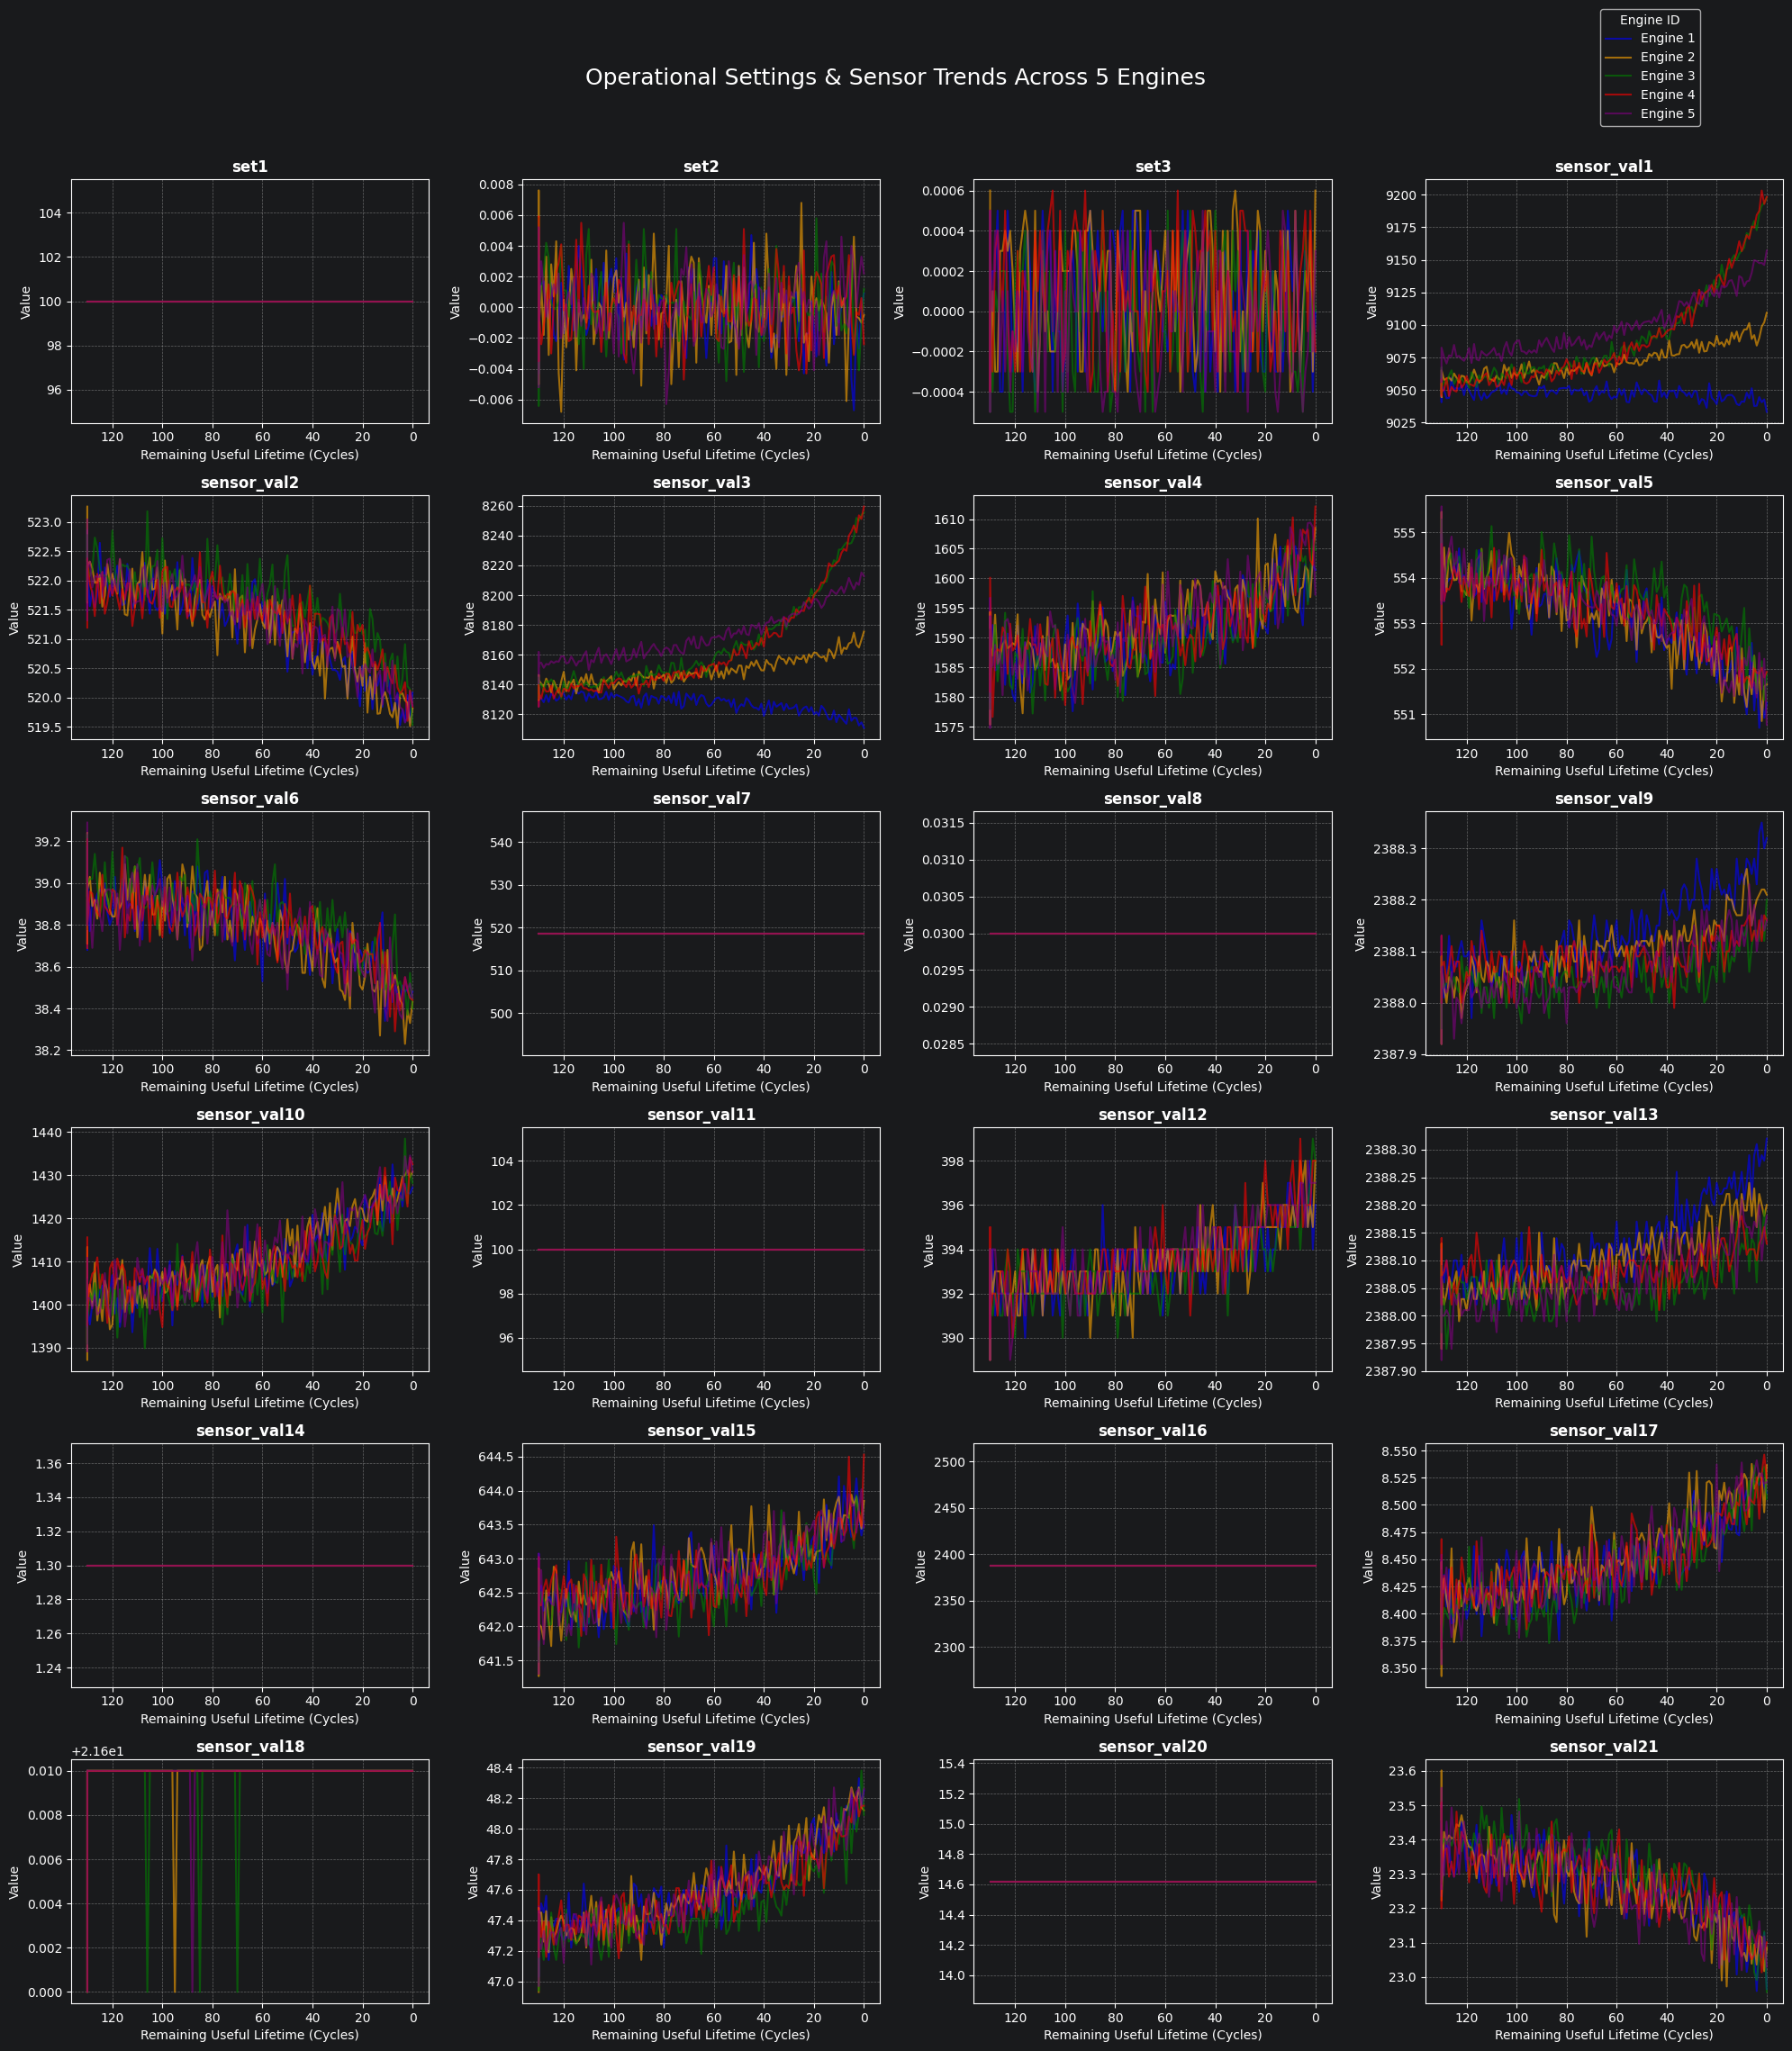

In [72]:
# Sample the first 5 engines to verify global degradation trends
engines_to_plot = [1, 2, 3, 4, 5]
features_to_plot = ['set1', 'set2', 'set3'] + [f'sensor_val{i}' for i in range(1, 22)]

# Initialize a 6x4 plotting grid
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
fig.suptitle('Operational Settings & Sensor Trends Across 5 Engines', fontsize=18, y=0.92)

axes = axes.flatten()
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    # Overlay line plots for each sampled engine
    for engine_id, color in zip(engines_to_plot, colors):
        engine_data = df_train[df_train['engine_id'] == engine_id]
        # Plotting against RUL standardizes the failure point (0) on the x-axis
        ax.plot(engine_data['RUL'], engine_data[feature], color=color, alpha=0.6, label=f'Engine {engine_id}')

    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Remaining Useful Lifetime (Cycles)')
    ax.set_ylabel('Value')
    ax.invert_xaxis() # Countdown to failure
    ax.grid(True, linestyle='--', alpha=0.5)

# Extract legend handles from the first subplot and apply figure-wide
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title="Engine ID")

plt.tight_layout(rect=[0, 0, 1, 0.9])

# Export visualization for reporting
plt.savefig('multi_engine_sensor_trends.png', bbox_inches='tight', dpi=300)
plt.show()

In [73]:
# Drop features identified as static/non-informative via visual analysis
useless_features = ['set1', 'sensor_val7','sensor_val8', 'sensor_val11','sensor_val14', 'sensor_val16', 'sensor_val20']
df_train.drop(columns=useless_features, inplace=True, errors='ignore')
df_schedule.drop(columns=useless_features, inplace=True, errors='ignore')

# Identify remaining operational columns for engineering
useful_cols = [col for col in df_train.columns if 'sensor' in col or 'set' in col]

# Generate rolling averages to smooth sensor noise (Window = 10 cycles)
window_size = 10

for col in useful_cols:
    df_train[f'{col}_roll_mean'] = df_train.groupby('engine_id')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
    df_schedule[f'{col}_roll_mean'] = df_schedule.groupby('engine_id')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())

print(f"Feature engineering complete. Current training matrix shape: {df_train.shape}")

Feature engineering complete. Current training matrix shape: (20631, 37)


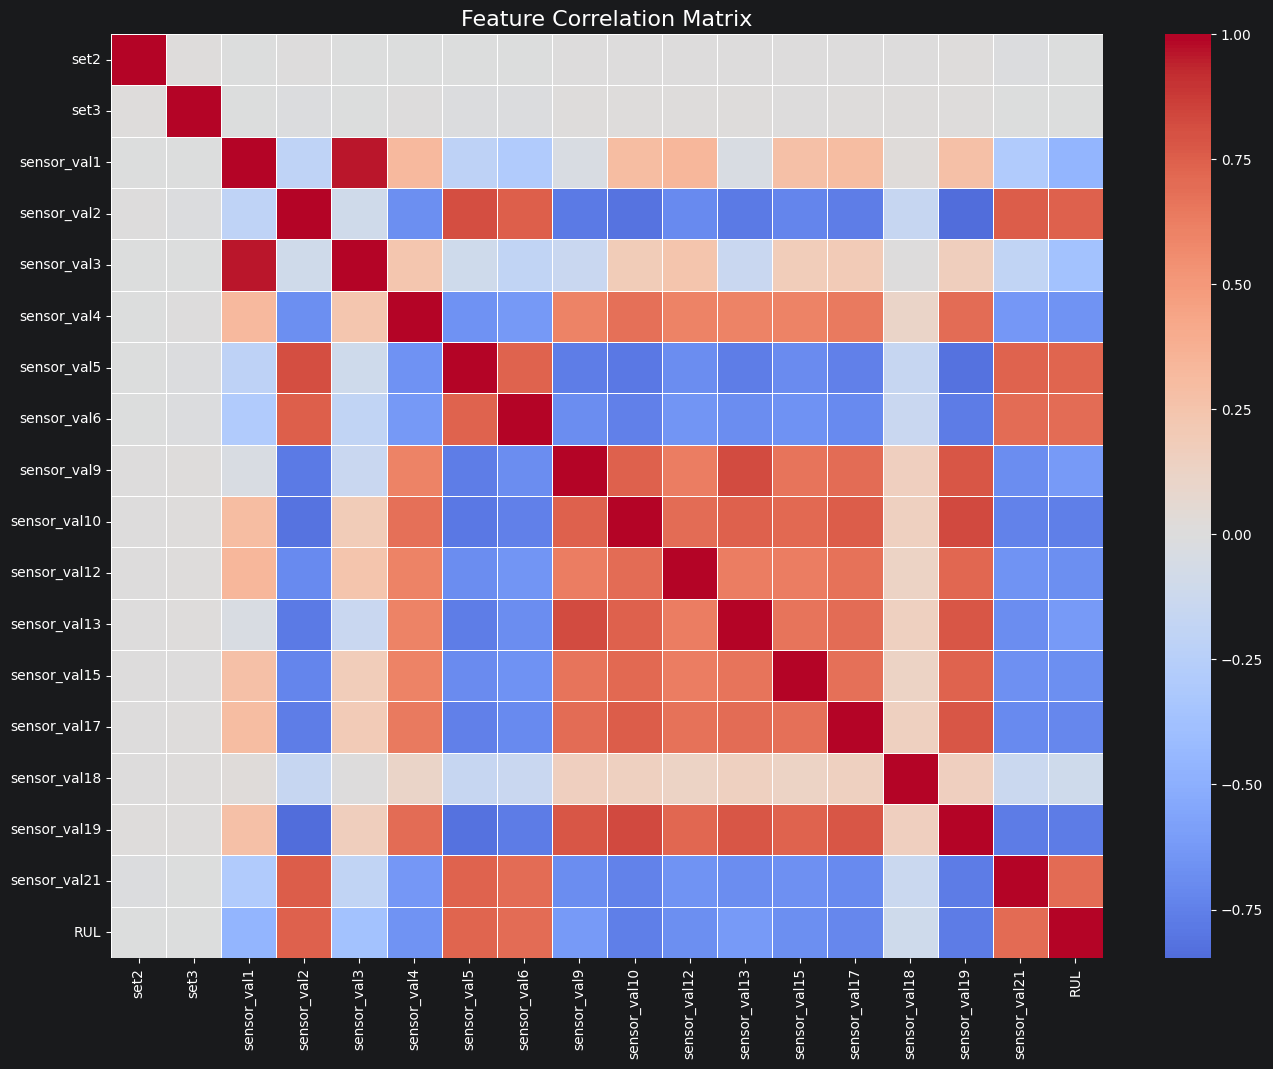

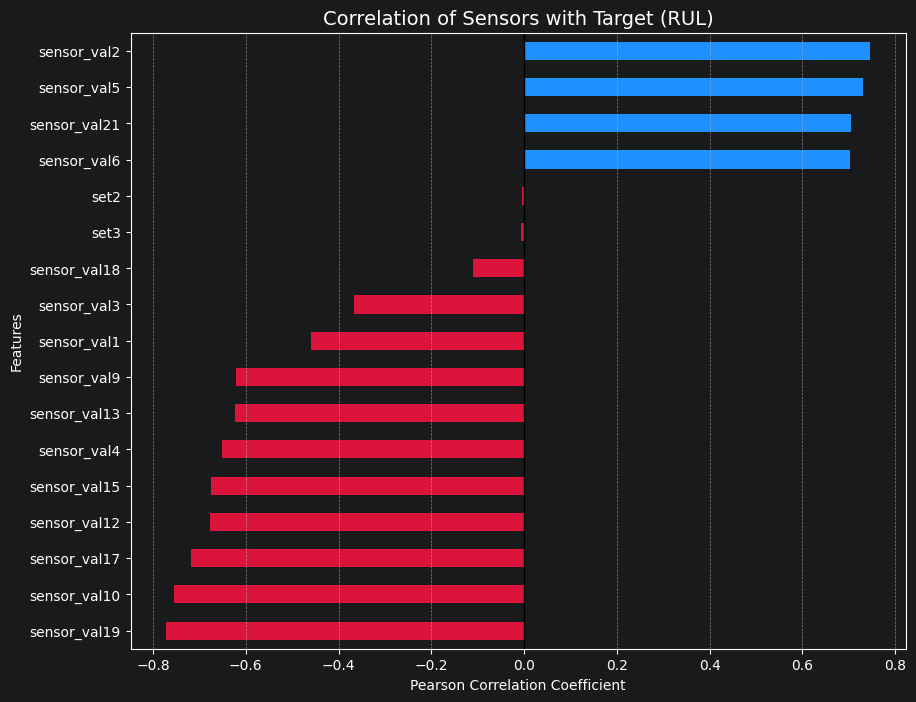

In [74]:
# Evaluate the linear relationship between remaining features and RUL
columns_for_corr = useful_cols + ['RUL']
corr_matrix = df_train[columns_for_corr].corr()

# Plot 1: Feature Multicollinearity Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Plot 2: Feature Importance (Correlation with RUL)
plt.figure(figsize=(10, 8))
rul_correlations = corr_matrix['RUL'].drop('RUL').sort_values()
rul_correlations.plot(kind='barh', color=np.where(rul_correlations < 0, 'crimson', 'dodgerblue'))
plt.title('Correlation of Sensors with Target (RUL)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.savefig('rul_correlation_bar_chart.png', bbox_inches='tight', dpi=300)
plt.show()

In [75]:
# Set an absolute correlation threshold to filter out weak predictors
CORR_THRESHOLD = 0.4

# Select features that meet the absolute correlation threshold
strong_features = rul_correlations[abs(rul_correlations) >= CORR_THRESHOLD].index.tolist()

# Update the final feature list to use the engineered rolling mean versions
final_features = [f"{feature}_roll_mean" for feature in strong_features if 'sensor' in feature or 'set' in feature]

print(f"Features retained after correlation thresholding (|r| >= {CORR_THRESHOLD}):")
for feature in final_features:
    print(f" - {feature}")

# Isolate the final independent (X) and dependent (y) variables for modeling
X = df_train[final_features]
y = df_train['RUL']

Features retained after correlation thresholding (|r| >= 0.4):
 - sensor_val19_roll_mean
 - sensor_val10_roll_mean
 - sensor_val17_roll_mean
 - sensor_val12_roll_mean
 - sensor_val15_roll_mean
 - sensor_val4_roll_mean
 - sensor_val13_roll_mean
 - sensor_val9_roll_mean
 - sensor_val1_roll_mean
 - sensor_val6_roll_mean
 - sensor_val21_roll_mean
 - sensor_val5_roll_mean
 - sensor_val2_roll_mean


In [76]:
from sklearn.model_selection import RandomizedSearchCV

# 80/20 train-test split for final holdout validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples\n")

# Initialize the baseline XGBoost Regressor
base_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# Define the hyperparameter search space
param_distributions = {
    'max_depth': [3, 4, 5, 6],  # Tree complexity
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size
    'n_estimators': [50, 100, 150, 200],  # Number of trees
    'subsample': [0.7, 0.8, 0.9, 1.0],  # Row sampling
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Feature sampling
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 Regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]  # L2 Regularization
}

# Set up Randomized Search (evaluating 20 random parameter combinations)
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter optimization")
random_search.fit(X_train, y_train)

# Extract the optimal model found during the search
xgb_model = random_search.best_estimator_

print("\nOptimal Hyperparameters Found")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

# The best cross-validation RMSE achieved during the search
best_cv_rmse = -random_search.best_score_
print(f"\nBest 5-Fold CV RMSE: {best_cv_rmse:.2f} cycles")

#Final evaluations
# Generate predictions on the 20% unseen test set using the tuned model
y_pred = xgb_model.predict(X_test)

# Calculate final evaluation metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print("Final Test Set Performance")
print(f"Test RMSE: {test_rmse:.2f} cycles")
print(f"Test MAE:  {test_mae:.2f} cycles")

Training set: 16504 samples
Testing set: 4127 samples

Starting hyperparameter optimization
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimal Hyperparameters Found
subsample: 1.0
reg_lambda: 1.0
reg_alpha: 0.1
n_estimators: 150
max_depth: 5
learning_rate: 0.2
colsample_bytree: 1.0

Best 5-Fold CV RMSE: 15.47 cycles
Final Test Set Performance
Test RMSE: 15.55 cycles
Test MAE:  10.76 cycles


In [77]:
from scipy import stats

# Extract the 'current' state of each engine in the schedule dataset
# By grouping by engine_id and taking the last row, we get the final recorded cycle
df_schedule_latest = df_schedule.groupby('engine_id').last().reset_index()

# Ensure we use the exact same engineered features we used for training
X_schedule = df_schedule_latest[final_features]

# Predict using our tuned XGBoost model
predictions = np.round(xgb_model.predict(X_schedule)).astype(int)

In [78]:
# Load the consultancy predictions
df_consultancy = pd.read_csv('RUL_consultancy_predictions_A3.csv', sep=';')
df_consultancy.head()
consultancy_raw = df_consultancy['RUL'].values

# Standardize the baseline (Clipping)
# Clip the consultancy predictions to my MAX_RUL (130) for a fair comparison
consultancy_clipped = np.clip(consultancy_raw, a_min=None, a_max=MAX_RUL)

# Check to make sure the lengths match before testing (both should be 100)
if len(predictions) != len(consultancy_clipped):
    print(f"Warning: Length mismatch. My: {len(your_predictions)}, Consultancy: {len(consultancy_clipped)}")

# Perform statistical testing
stat, p_value = stats.wilcoxon(predictions, consultancy_clipped)

print("Prediction Comparison Results")
print(f"Mean Prediction (My):          {predictions.mean():.2f} cycles")
print(f"Mean Prediction (Consultancy): {consultancy_clipped.mean():.2f} cycles")
print(f"Wilcoxon Test p-value:         {p_value:.5e}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference between my predictions and the consultancy's.")
else:
    print("\nConclusion: There is no statistically significant difference between the predictions.")

Prediction Comparison Results
Mean Prediction (My):          80.85 cycles
Mean Prediction (Consultancy): 79.48 cycles
Wilcoxon Test p-value:         9.55679e-01

Conclusion: There is NO statistically significant difference between the predictions.
